In [1]:
from IPython.display import display
import typing as t

import matplotlib.pyplot as plt
import polars as pl

from src.config.constants import Product
from src.research import (
    AnalysisResult,
    OrderbookAnalysisResult,
    Plots,
    TradesAnalysisResult,
    run_analysis,
    display_plots,
)

EMERALDS: t.Final[Product] = Product.EMERALDS
ROUND: t.Final[int] = 0
DAY: t.Final[int] = -1

analysis_result: AnalysisResult = run_analysis(ROUND, DAY, EMERALDS)
orderbook_analysis: OrderbookAnalysisResult = analysis_result.orderbook_analysis_result
trades_analysis: TradesAnalysisResult = analysis_result.trades_analysis_result

# Orderbook Analysis

In [2]:
orderbook_data: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_data
orderbook_features_data: t.Final[pl.DataFrame] = (
    orderbook_analysis.orderbook_features_data
)
orderbook_stats: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_stats
orderbook_corrs: t.Final[pl.DataFrame] = orderbook_analysis.orderbook_corrs

orderbook_data

timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64,f64,i64
0,9992,14,9990,29,null,null,10008,14,10010,29,null,null,10000.0,16,0.0,null,0.0,10000.0,0.0,28
100,9992,11,9990,22,null,null,10008,11,10010,22,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,22
200,9992,15,9990,20,null,null,10008,15,10010,20,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,30
300,9992,11,9990,29,null,null,10008,11,10010,29,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,22
400,9992,12,9990,25,null,null,10008,12,10010,25,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999500,9992,14,9990,29,null,null,10008,14,10010,29,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,28
999600,9992,14,9990,28,null,null,10008,14,10010,28,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,28
999700,9992,12,9990,26,null,null,10008,12,10010,26,null,null,10000.0,16,0.0,0.0,0.0,10000.0,0.0,24


In [3]:
orderbook_features_data

timestamp,mid_price,spread,imbalance,log_returns,future_log_returns,microprice,microprice_dev,depth
i64,f64,i64,f64,f64,f64,f64,f64,i64
0,10000.0,16,0.0,null,0.0,10000.0,0.0,28
100,10000.0,16,0.0,0.0,0.0,10000.0,0.0,22
200,10000.0,16,0.0,0.0,0.0,10000.0,0.0,30
300,10000.0,16,0.0,0.0,0.0,10000.0,0.0,22
400,10000.0,16,0.0,0.0,0.0,10000.0,0.0,24
…,…,…,…,…,…,…,…,…
999500,10000.0,16,0.0,0.0,0.0,10000.0,0.0,28
999600,10000.0,16,0.0,0.0,0.0,10000.0,0.0,28
999700,10000.0,16,0.0,0.0,0.0,10000.0,0.0,24


In [4]:
orderbook_stats

mid_mean,mid_var,mid_std,micro_mean,micro_var,micro_std,ret_mean,ret_var,ret_std
f64,f64,f64,f64,f64,f64,f64,f64,f64
9999.998,0.513647,0.716692,9999.996875,0.297615,0.545541,-1.1841e-18,9.9860e-9,0.0001


In [5]:
orderbook_corrs

imb_corr,micro_corr
f64,f64
-0.682095,0.623274


## Conclusion

### Returns analysis
Given that the mean and variance of the log returns for emeralds is essentially 0, the price of Emeralds is essentially constant and fixed at the mid_price of 10000 XIRECS. The lack of any meaningful drift of the price (which would have been indicated in the returns) means that there is no directional edge present from the price itself and emeralds must be traded as a maker rather than a taker.

### Correlation analysis
- *Imbalance & future returns*: Counterintuitively, the data suggests that when there is buying pressure, the returns decrease. But considering the fact that this is a limit order book, this conclusion makes sense. During times of high bidding pressure, sellers are attracted who send out sell market orders which actually influence the price (rather than the liquidity provided by limit orders). This further implies an increase in inventory risk during times of high imbalance signalling to join the selling pressure to square off long positions.
- *Microprice deviations & future returns*: When microprice is higher than midprice, there is a tendency for the midprice to catch up. Even though the price is relatively constant, the orderbook suggests short term moves. 

# Trades Analysis

In [6]:
trades_data: t.Final[pl.DataFrame] = trades_analysis.trades_data
time_interval_stats: t.Final[pl.DataFrame] = trades_analysis.time_interval_stats
trades_plots: t.Final[Plots] = trades_analysis.plots

trades_data

timestamp,price,quantity,best_bid,best_ask,mid_price,time_since_prev_trade,time_until_next_trade,mid_price_dev,side_heur
i64,f64,i64,i64,i64,f64,i64,i64,f64,str
3200,9992.0,8,9992,10008,10000.0,null,1800,-8.0,"""SELL_ORDER"""
5000,9992.0,7,9992,10000,9996.0,1800,26400,-4.0,"""SELL_ORDER"""
31400,10008.0,3,9992,10008,10000.0,26400,8500,8.0,"""BUY_ORDER"""
39900,9992.0,7,9992,10008,10000.0,8500,2500,-8.0,"""SELL_ORDER"""
42400,9992.0,5,9992,10008,10000.0,2500,8900,-8.0,"""SELL_ORDER"""
…,…,…,…,…,…,…,…,…,…
973400,10008.0,8,9992,10008,10000.0,500,5800,8.0,"""BUY_ORDER"""
979200,10008.0,6,9992,10008,10000.0,5800,3700,8.0,"""BUY_ORDER"""
982900,10008.0,6,9992,10008,10000.0,3700,900,8.0,"""BUY_ORDER"""


In [7]:
time_interval_stats

time_since_prev_mean,time_since_prev_var,time_since_prev_std,time_until_next_mean,time_until_next_var,time_until_next_std
f64,f64,f64,f64,f64,f64
4745.89372,2.2520e7,4745.521143,4745.89372,2.2520e7,4745.521143


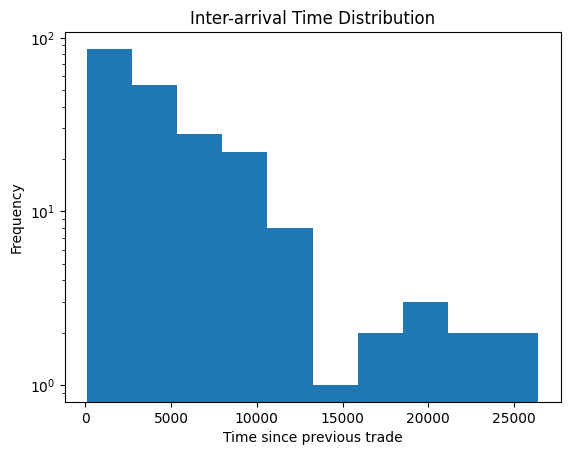

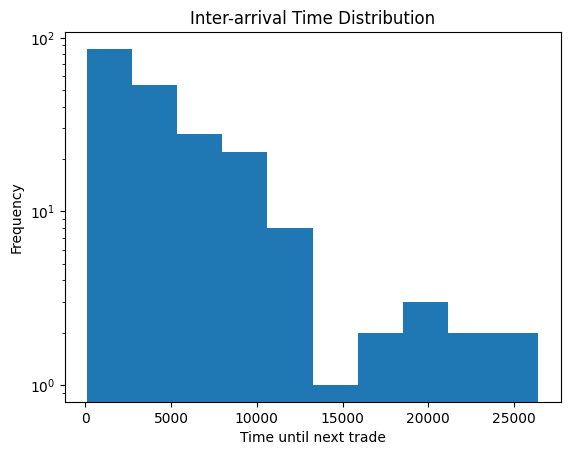

In [8]:
display_plots(trades_plots)